In [7]:
import pandas as pd

df_all = pd.read_csv("data-Jun24/pqm_extract.csv")

df = df_all[
    df_all["PlanId"].fillna("").str.contains("/", regex=False)
].copy()

df["Value"] = pd.to_numeric(df["Value"], errors="coerce")

plan_counts = (
    df[["PatientId", "CourseId", "PlanId"]]
    .drop_duplicates()
    .groupby(["PatientId", "CourseId"])
    .size()
)

summary = pd.DataFrame([{
    "OriginalRows": len(df_all),
    "RowsWithSlashPlanId": len(df),
    "Patients": df["PatientId"].nunique(),
    "Sessions": df[["PatientId", "CourseId"]].drop_duplicates().shape[0],
    "Plans": df[["PatientId", "CourseId", "PlanId"]].drop_duplicates().shape[0],
    "Metrics": df["MetricId"].nunique(),
    "PlanCountMinPerSession": plan_counts.min(),
    "PlanCountMaxPerSession": plan_counts.max(),
    "RowsExpected": (
        df[["PatientId", "CourseId", "PlanId"]].drop_duplicates().shape[0]
        * df["MetricId"].nunique()
    ),
    "RowsActual": len(df)
}])

display(summary)

display(df["Status"].value_counts(dropna=False).rename("StatusCount"))
display(df["MetricId"].value_counts().rename("MetricCount"))
display(
    df[["PatientId", "CourseId"]]
    .drop_duplicates()
    .groupby("PatientId")
    .size()
    .rename("SessionsPerPatient")
)
display(plan_counts.value_counts().sort_index().rename("SessionsByPlanCount"))

,OriginalRows,RowsWithSlashPlanId,Patients,Sessions,Plans,Metrics,PlanCountMinPerSession,PlanCountMaxPerSession,RowsExpected,RowsActual
0,3110,3110,10,311,622,5,2,2,3110,3110


Status
OkNormalized    3110
Name: StatusCount, dtype: int64

MetricId
V95% PTV2                  622
V95% PTV3                  622
V107%/V64.2Gy PTV2-PTV1    622
V107%/V53.5Gy PTV3-PTV2    622
D1.8cm3 PTV1               622
Name: MetricCount, dtype: int64

PatientId
99DART-HN_1     34
99DART-HN_10    23
99DART-HN_2     34
99DART-HN_3     34
99DART-HN_4     34
99DART-HN_5     34
99DART-HN_6     34
99DART-HN_7     17
99DART-HN_8     33
99DART-HN_9     34
Name: SessionsPerPatient, dtype: int64

2    311
Name: SessionsByPlanCount, dtype: int64

MetricId,PatientId,CourseId,PlanId,D1.8cm3 PTV1,V107%/V53.5Gy PTV3-PTV2,V107%/V64.2Gy PTV2-PTV1,V95% PTV2,V95% PTV3
count,622,622,622,622.000000,622.000000,622.000000,622.000000,622.000000
unique,10,34,622,NaN,NaN,NaN,NaN,NaN
top,99DART-HN_1,Session 1,IM111/ADP0102,NaN,NaN,NaN,NaN,NaN
freq,68,20,1,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,52.940011,1.169918,14.393696,53.454434,56.622322
std,NaN,NaN,NaN,21.599478,2.656106,19.561157,48.558200,45.269200
min,NaN,NaN,NaN,2.093000,0.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,NaN,37.177500,0.000000,0.000000,0.000000,0.000000
50%,NaN,NaN,NaN,63.828500,0.000000,0.000000,89.505000,69.630500
75%,NaN,NaN,NaN,70.385750,0.591500,27.387250,99.666750,99.867500


,count,mean,std,min,25%,50%,75%,max
MetricId,,,,,,,,
D1.8cm3 PTV1,622.0,52.940,21.599,2.093,37.178,63.829,70.386,80.927
V107%/V53.5Gy PTV3-PTV2,622.0,1.170,2.656,0.000,0.000,0.000,0.591,14.432
V107%/V64.2Gy PTV2-PTV1,622.0,14.394,19.561,0.000,0.000,0.000,27.387,65.334
V95% PTV2,622.0,53.454,48.558,0.000,0.000,89.505,99.667,99.998
V95% PTV3,622.0,56.622,45.269,0.000,0.000,69.630,99.867,100.000


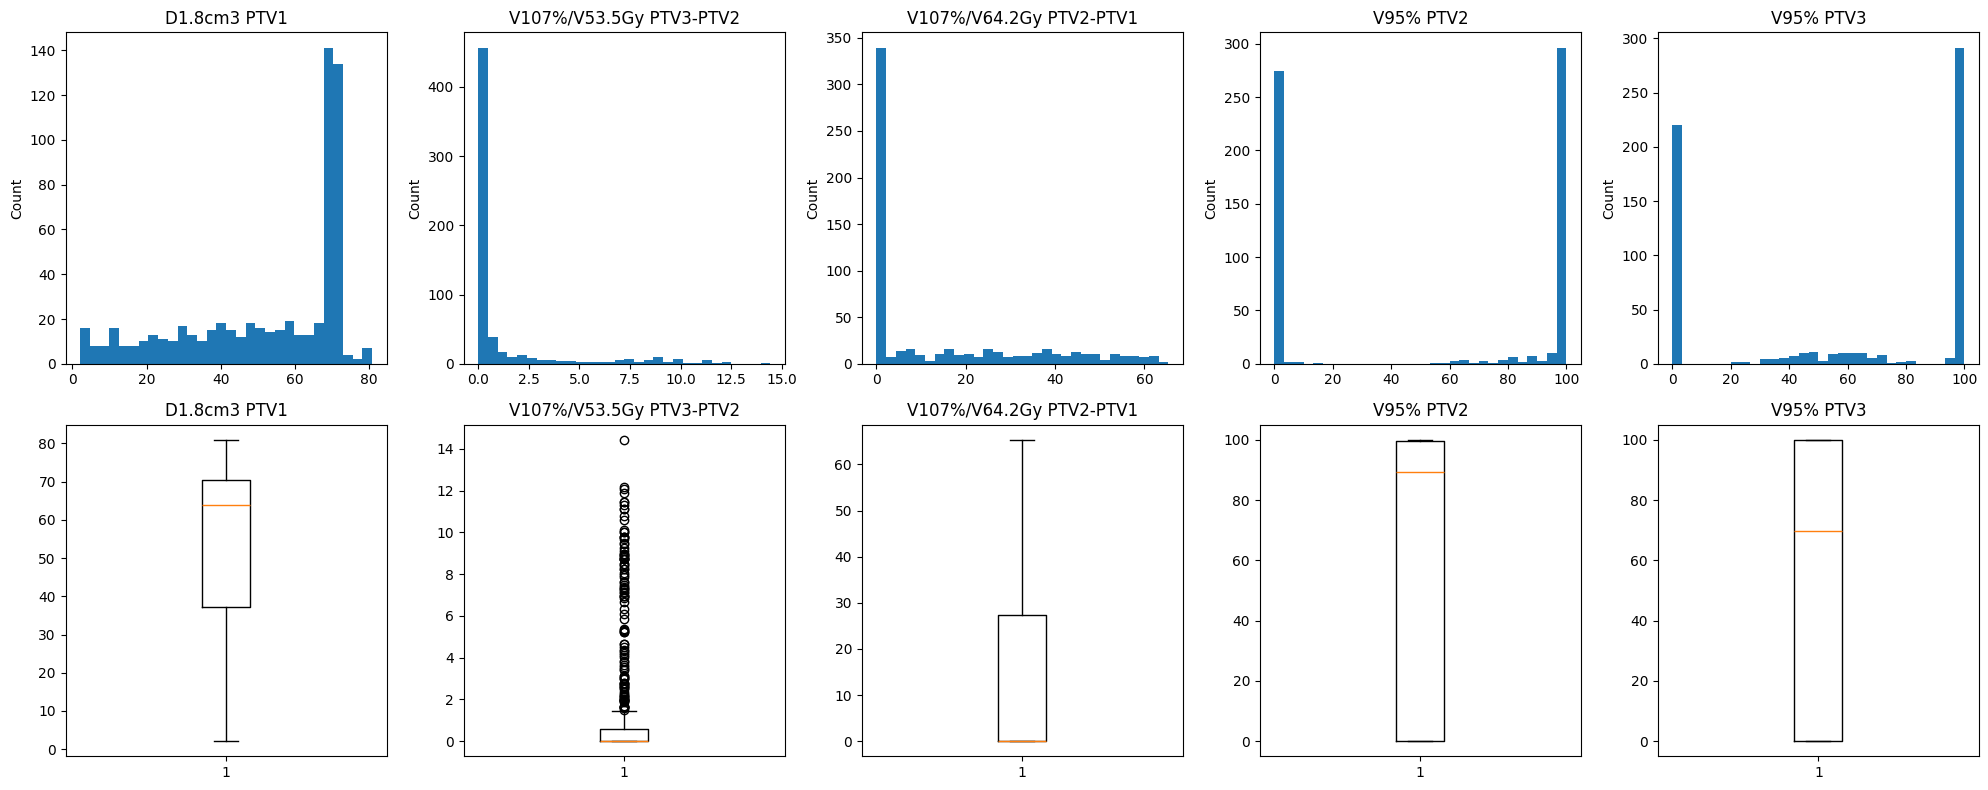

In [8]:
import matplotlib.pyplot as plt

df_ok = df[df["Status"].astype(str).str.startswith("Ok")].copy()
df_ok["Value"] = pd.to_numeric(df_ok["Value"], errors="coerce")

wide = (
    df_ok.pivot_table(
        index=["PatientId", "CourseId", "PlanId"],
        columns="MetricId",
        values="Value",
        aggfunc="first"
    )
    .reset_index()
)

display(wide.describe(include="all"))
display(
    df_ok.groupby("MetricId")["Value"]
    .describe()
    .round(3)
)

metrics = sorted(df_ok["MetricId"].unique())

fig, axes = plt.subplots(2, len(metrics), figsize=(4 * len(metrics), 8))

for i, metric in enumerate(metrics):
    values = df_ok.loc[df_ok["MetricId"] == metric, "Value"].dropna()

    axes[0, i].hist(values, bins=30)
    axes[0, i].set_title(metric)
    axes[0, i].set_ylabel("Count")

    axes[1, i].boxplot(values, vert=True)
    axes[1, i].set_title(metric)

plt.tight_layout()
plt.show()

In [9]:
tmp = df_ok.copy()
tmp["PlanFamily"] = tmp["PlanId"].str.extract(r"/([A-Za-z]+)", expand=False).fillna("Unknown")

report = (
    tmp.groupby(["MetricId", "PlanFamily"])["Value"]
    .agg(
        Count="count",
        Min="min",
        Q1=lambda x: x.quantile(0.25),
        Median="median",
        Q3=lambda x: x.quantile(0.75),
        Max="max",
        ZeroCount=lambda x: (x == 0).sum(),
        NearZeroCount=lambda x: (x < 1).sum(),
    )
    .round(3)
    .reset_index()
)

display(report)

# show the actual low V95 plans
display(
    tmp[
        (tmp["MetricId"].isin(["V95% PTV2", "V95% PTV3"]))
        & (tmp["Value"] < 1)
    ][["PatientId", "CourseId", "PlanId", "RequestedStructureId", "ActualStructureId", "MetricId", "MayoQuery", "Value", "Status"]]
    .sort_values(["MetricId", "PatientId", "CourseId", "PlanId"])
    .head(80)
)


,MetricId,PlanFamily,Count,Min,Q1,Median,Q3,Max,ZeroCount,NearZeroCount
0,D1.8cm3 PTV1,ADP,311,2.093,36.898,63.453,70.213,72.637,0,0
1,D1.8cm3 PTV1,SCH,311,2.097,37.472,64.209,70.503,80.927,0,0
2,V107%/V53.5Gy PTV3-PTV2,ADP,311,0.000,0.000,0.000,0.096,8.948,176,287
3,V107%/V53.5Gy PTV3-PTV2,SCH,311,0.000,0.000,0.000,1.976,14.432,160,208
4,V107%/V64.2Gy PTV2-PTV1,ADP,311,0.000,0.000,0.000,15.742,62.782,157,172
5,V107%/V64.2Gy PTV2-PTV1,SCH,311,0.000,0.000,0.002,38.643,65.334,155,164
6,V95% PTV2,ADP,311,0.000,0.000,90.607,99.912,99.998,132,135
7,V95% PTV2,SCH,311,0.000,0.000,89.225,99.332,99.979,129,133
8,V95% PTV3,ADP,311,0.000,0.000,68.987,99.963,100.000,104,110
9,V95% PTV3,SCH,311,0.000,0.000,70.300,99.701,100.000,101,108


,PatientId,CourseId,PlanId,RequestedStructureId,ActualStructureId,MetricId,MayoQuery,Value,Status
2895,99DART-HN_10,Session 10,IM157/ADP1003,PTV2,PTV2_60,V95% PTV2,V57Gy[%],0.0,OkNormalized
2890,99DART-HN_10,Session 10,IM157/SCH1004,PTV2,PTV2_60,V95% PTV2,V57Gy[%],0.0,OkNormalized
2900,99DART-HN_10,Session 11,IM157/ADP1104,PTV2,PTV2_60,V95% PTV2,V57Gy[%],0.0,OkNormalized
2905,99DART-HN_10,Session 11,IM157/SCH1103,PTV2,PTV2_60,V95% PTV2,V57Gy[%],0.0,OkNormalized
2915,99DART-HN_10,Session 12,IM157/ADP1203,PTV2,PTV2_60,V95% PTV2,V57Gy[%],0.0,OkNormalized
...,...,...,...,...,...,...,...,...,...
1605,99DART-HN_5,Session 31,IM113/SCH3104,PTV2,PTV2_60,V95% PTV2,V57Gy[%],0.0,OkNormalized
1615,99DART-HN_5,Session 32,IM113/ADP3203,PTV2,PTV2_60,V95% PTV2,V57Gy[%],0.0,OkNormalized
1610,99DART-HN_5,Session 32,IM113/SCH3204,PTV2,PTV2_60,V95% PTV2,V57Gy[%],0.0,OkNormalized
1620,99DART-HN_5,Session 33,IM113/ADP3304,PTV2,PTV2_60,V95% PTV2,V57Gy[%],0.0,OkNormalized


In [10]:
display(
    df.groupby(
        ["RequestedStructureId",
         "ActualStructureId",
         "Status"]
    )
    .size()
    .reset_index(name="Count")
    .sort_values("Count", ascending=False)
)


,RequestedStructureId,ActualStructureId,Status,Count
2,PTV2,PTV2_60,OkNormalized,622
5,PTV3,PTV3_50,OkNormalized,622
6,PTV3-PTV2,PTV3_50-PTV2_60,OkNormalized,622
4,PTV2-PTV1,PTV2_60-PTV1_68,OkNormalized,556
1,PTV1,PTV1_68,OkNormalized,556
0,PTV1,PTV1_66,OkNormalized,66
3,PTV2-PTV1,PTV2_60-PTV1_66,OkNormalized,66


MetricId,PatientId,CourseId,PlanId,D1.8cm3 PTV1,V95% PTV2,V95% PTV3,V107%/V64.2Gy PTV2-PTV1,V107%/V53.5Gy PTV3-PTV2
70,99DART-HN_10,Session 10,IM157/ADP1003,51.385,0.0,51.365,0.0,0.0
71,99DART-HN_10,Session 10,IM157/SCH1004,51.854,0.0,48.261,0.0,0.0
72,99DART-HN_10,Session 11,IM157/ADP1104,49.237,0.0,37.082,0.0,0.0
73,99DART-HN_10,Session 11,IM157/SCH1103,50.229,0.0,38.597,0.0,0.0
74,99DART-HN_10,Session 12,IM157/ADP1203,47.182,0.0,0.040,0.0,0.0
...,...,...,...,...,...,...,...,...
397,99DART-HN_6,Session 14,IM122/SCH1403,42.957,0.0,0.000,0.0,0.0
398,99DART-HN_6,Session 15,IM122/ADP1504,40.798,0.0,0.000,0.0,0.0
399,99DART-HN_6,Session 15,IM122/SCH1503,40.925,0.0,0.000,0.0,0.0
400,99DART-HN_6,Session 16,IM122/ADP1604,38.740,0.0,0.000,0.0,0.0


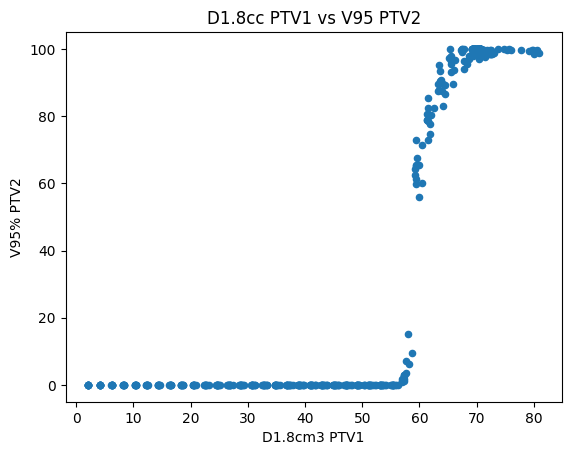

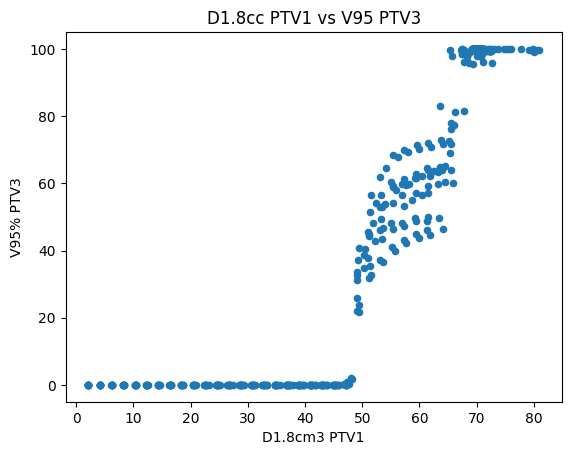

In [11]:
import matplotlib.pyplot as plt

wide = (
    df.pivot_table(
        index=["PatientId", "CourseId", "PlanId"],
        columns="MetricId",
        values="Value",
        aggfunc="first"
    )
    .reset_index()
)

display(
    wide[
        (wide["V95% PTV2"] < 1) | (wide["V95% PTV3"] < 1)
    ][[
        "PatientId", "CourseId", "PlanId",
        "D1.8cm3 PTV1",
        "V95% PTV2",
        "V95% PTV3",
        "V107%/V64.2Gy PTV2-PTV1",
        "V107%/V53.5Gy PTV3-PTV2"
    ]]
    .sort_values(["PatientId", "CourseId", "PlanId"])
    .head(100)
)

wide.plot.scatter(x="D1.8cm3 PTV1", y="V95% PTV2", title="D1.8cc PTV1 vs V95 PTV2")
plt.show()

wide.plot.scatter(x="D1.8cm3 PTV1", y="V95% PTV3", title="D1.8cc PTV1 vs V95 PTV3")
plt.show()

In [12]:
wide[
    (wide["V95% PTV2"] < 1)
    & (wide["D1.8cm3 PTV1"] > 60)
].sort_values("D1.8cm3 PTV1", ascending=False)

MetricId,PatientId,CourseId,PlanId,D1.8cm3 PTV1,V107%/V53.5Gy PTV3-PTV2,V107%/V64.2Gy PTV2-PTV1,V95% PTV2,V95% PTV3
